# Figure 6 — R² performance: Generalisable vs Fit-Biased model configuration

Loads `Results_{target}.csv` from `Original_DS` and `Stress_Test`, builds a
summary table, and produces publication-ready bar charts.

**Generalisable**: grid-search config trained on original data (`Original_DS/`).
**Fit-Biased**: stress-test config (empirically overfitted, `Stress_Test/`).

Both datasets evaluated on the **original (unfiltered) test set** (`Test_original`).

In [6]:
import sys
from pathlib import Path

# figures/ → fig_style.py  |  bp_lgbm/ → local_paths.py
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path("../").resolve()))

from fig_style import (
    DPI, W_FULL, W_SINGLE, ASPECT, FONT_FAMILY,
    MIN_PX_FULL, MIN_PX_SINGLE,
    apply_base_style, save_fig,
)
from local_paths import PERFORMANCE_RESULTS_PAPER, FIGURES_PAPER

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

FIG_OUT = FIGURES_PAPER
FIG_OUT.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {FIG_OUT.resolve()}")
print(f"Full-page : {W_FULL:.2f} × {W_FULL*ASPECT:.2f} in  →  {round(W_FULL*DPI)} × {round(W_FULL*ASPECT*DPI)} px @ {DPI} dpi")
print(f"Single-col: {W_SINGLE:.2f} × {W_SINGLE*ASPECT:.2f} in  →  {round(W_SINGLE*DPI)} × {round(W_SINGLE*ASPECT*DPI)} px @ {DPI} dpi")

Output directory: C:\Users\addp972\OneDrive - City, University of London\3.PhD\9. Experiments\2.LightGBM_SHAP\Figures_SummaryTables
Full-page : 7.48 × 4.86 in  →  3740 × 2431 px @ 500 dpi
Single-col: 3.54 × 2.30 in  →  1770 × 1150 px @ 500 dpi


## 1 · Load results

In [7]:
TARGETS = ["SBP", "DBP", "MAP"]

def load_experiment(folder: str, targets=TARGETS) -> dict[str, pd.DataFrame]:
    """Load Results_{target}.csv for each target from a subfolder of PERFORMANCE_RESULTS_PAPER."""
    base = PERFORMANCE_RESULTS_PAPER / folder
    dfs = {}
    for t in targets:
        p = base / f"Results_{t}.csv"
        raw = p.read_text(encoding="utf-8")
        sep = ";" if raw.count(";") > raw.count(",") else ","
        df = pd.read_csv(p, sep=sep)
        df.columns = df.columns.str.strip()
        df["Data_Subset"] = df["Data_Subset"].str.strip()
        df.set_index("Data_Subset", inplace=True)
        dfs[t] = df
        print(f"  {folder}/{t}: rows = {list(df.index)}")
    return dfs

print("Loading Original_DS (Generalisable) …")
gs = load_experiment("Original_DS")

print("\nLoading Stress_Test (Fit-Biased) …")
st = load_experiment("Stress_Test")

Loading Original_DS (Generalisable) …
  Original_DS/SBP: rows = ['Train', 'Val', 'Test_original', 'Test_80', 'Test_90']
  Original_DS/DBP: rows = ['Train', 'Val', 'Test_original', 'Test_80', 'Test_90']
  Original_DS/MAP: rows = ['Train', 'Val', 'Test_original', 'Test_80', 'Test_90']

Loading Stress_Test (Fit-Biased) …
  Stress_Test/SBP: rows = ['Train', 'Val', 'Test_original']
  Stress_Test/DBP: rows = ['Train', 'Val', 'Test_original']
  Stress_Test/MAP: rows = ['Train', 'Val', 'Test_original']


## 2 · Build summary table

Both configurations evaluated on **Test_original** (unfiltered test set).

In [8]:
rows = []
for target in TARGETS:
    for split, row_key, ds_label, ds in [
        ("Train", "Train",         "Generalisable", gs),
        ("Test",  "Test_original", "Generalisable", gs),
        ("Train", "Train",         "Fit-Biased",    st),
        ("Test",  "Test_original", "Fit-Biased",    st),
    ]:
        r2 = ds[target].loc[row_key, "R2"]
        rows.append({"Target": target, "Split": split, "Dataset": ds_label, "R2": r2})

summary = pd.DataFrame(rows)
summary["R2_pct"] = summary["R2"] * 100

pivot = summary.pivot_table(index=["Target", "Split"], columns="Dataset", values="R2_pct")
pivot = pivot[["Generalisable", "Fit-Biased"]]
print(pivot.round(2).to_string())
pivot.round(4).to_csv(FIG_OUT / "Table_R2_GeneralisableVsFitBiased.csv")
print(f"\n✅ Table saved → {FIG_OUT / 'Table_R2_GeneralisableVsFitBiased.csv'}")

Dataset       Generalisable  Fit-Biased
Target Split                           
DBP    Test           19.49       18.12
       Train          26.35       58.53
MAP    Test           24.97       24.67
       Train          33.58       62.83
SBP    Test           19.94       18.05
       Train          29.31       60.04

✅ Table saved → C:\Users\addp972\OneDrive - City, University of London\3.PhD\9. Experiments\2.LightGBM_SHAP\Figures_SummaryTables\Table_R2_GeneralisableVsFitBiased.csv


## 3 · Plot — grouped bar chart

Full page : 3740 × 2431 px
Single col: 1770 × 1150 px


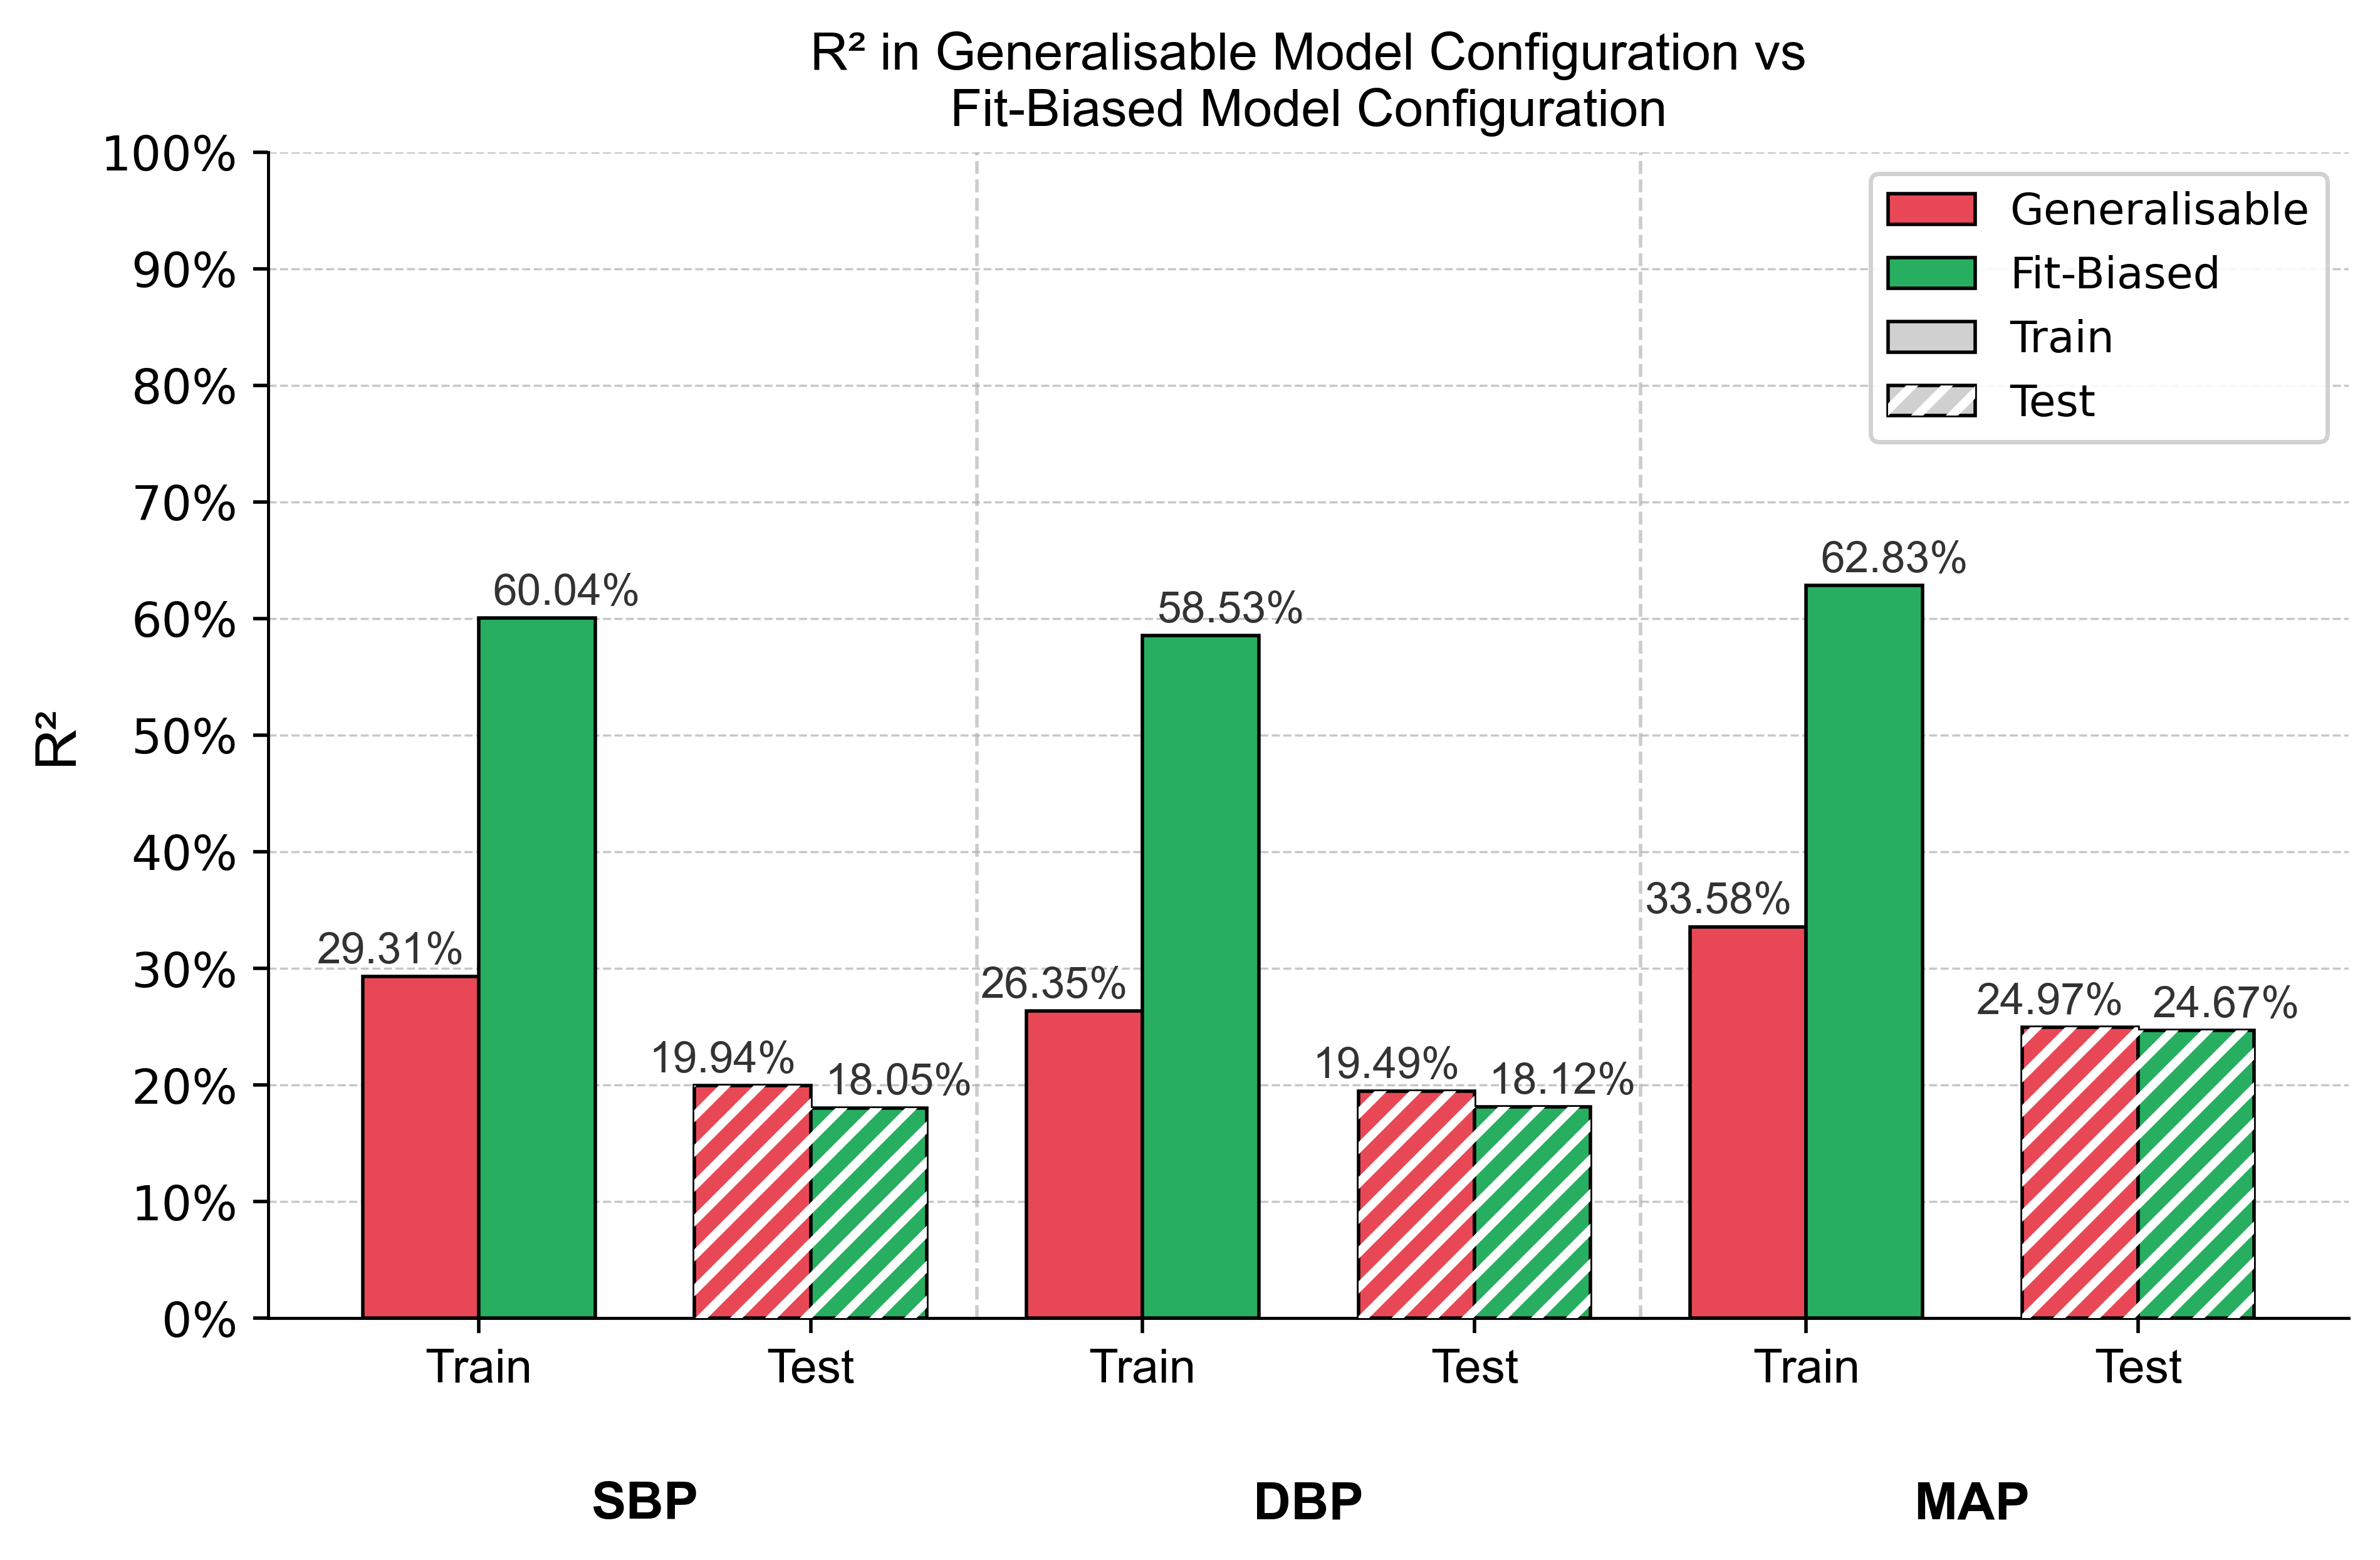

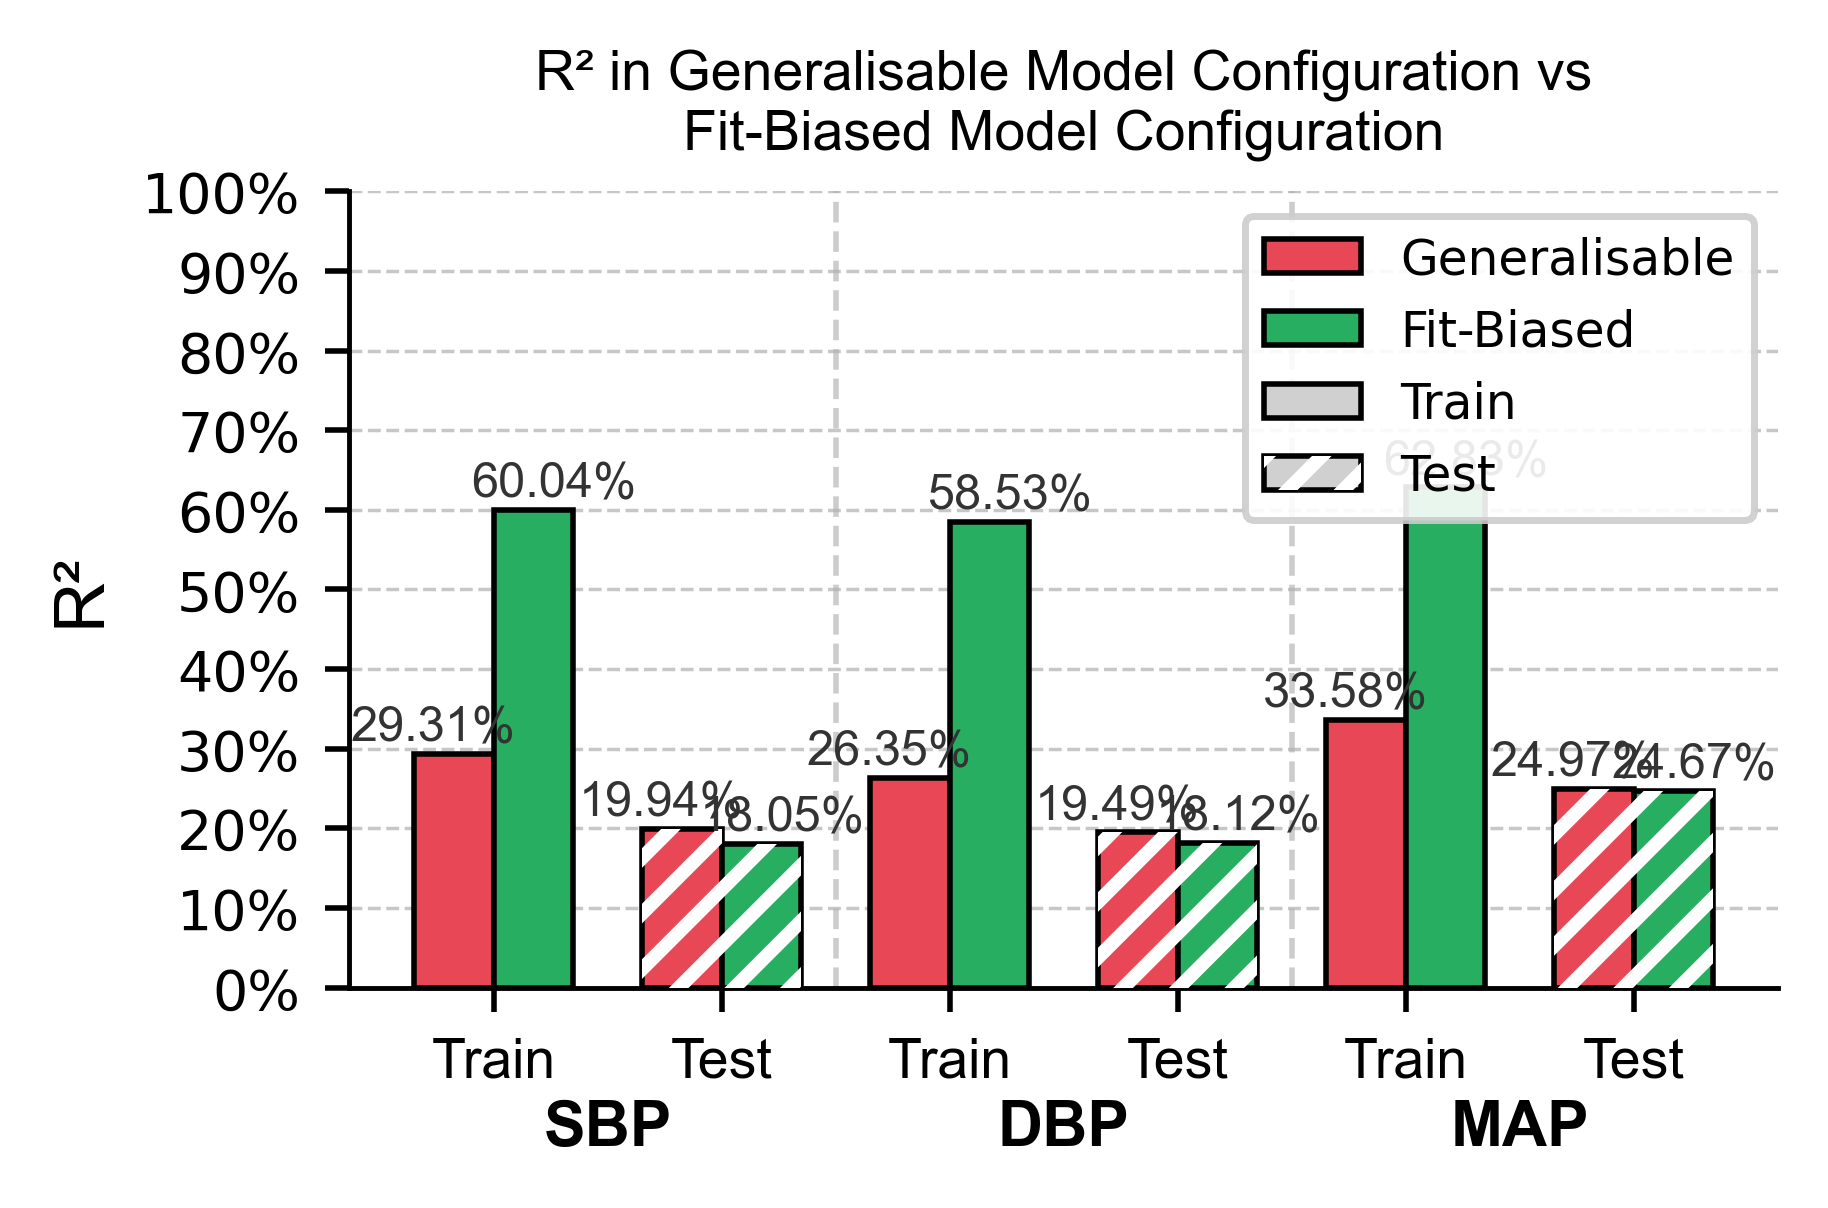

In [9]:
# ── Figure-specific palette ──
COLOR_GS    = "#E84855"   # Watermelon  → Generalisable (GS config)
COLOR_ST    = "#27AE60"   # green       → Fit-Biased (stress-test config)
HATCH_TEST  = "///"       # Test split
BAR_WIDTH   = 0.35
LABEL_NUDGE = 0.09        # data-unit nudge: GS left, ST right

# X ordering: Train SBP, Test SBP, Train DBP, Test DBP, Train MAP, Test MAP
order = [(t, s) for t in TARGETS for s in ["Train", "Test"]]
x     = np.arange(len(order))

gs_vals, st_vals = [], []
for target, split in order:
    row = summary.query("Target == @target and Split == @split")
    gs_vals.append(row.query("Dataset == 'Generalisable'")["R2_pct"].values[0])
    st_vals.append(row.query("Dataset == 'Fit-Biased'")["R2_pct"].values[0])


def make_r2_barchart(width_in: float):
    _prev_hatch_lw = mpl.rcParams['hatch.linewidth']
    mpl.rcParams['hatch.linewidth'] = 2.0

    fig, ax = plt.subplots(figsize=(width_in, width_in * ASPECT),
                           dpi=DPI, layout="constrained")

    # Pass 1: solid fill + black outline; Pass 2: white-hatch overlay for Test
    all_bars = []  # (rect, "gs" | "st")
    for i, (target, split) in enumerate(order):
        is_test = split == "Test"

        bc1 = ax.bar(i - BAR_WIDTH/2, gs_vals[i], BAR_WIDTH,
                     color=COLOR_GS, facecolor=COLOR_GS,
                     edgecolor="black", linewidth=0.8, zorder=3)
        bc2 = ax.bar(i + BAR_WIDTH/2, st_vals[i], BAR_WIDTH,
                     color=COLOR_ST, facecolor=COLOR_ST,
                     edgecolor="black", linewidth=0.8, zorder=3)

        if is_test:
            ax.bar(i - BAR_WIDTH/2, gs_vals[i], BAR_WIDTH,
                   facecolor="none", hatch=HATCH_TEST,
                   edgecolor="white", linewidth=0, zorder=3)
            ax.bar(i + BAR_WIDTH/2, st_vals[i], BAR_WIDTH,
                   facecolor="none", hatch=HATCH_TEST,
                   edgecolor="white", linewidth=0, zorder=3)

        all_bars.extend([(bc1[0], "gs"), (bc2[0], "st")])

    # Data labels — GS nudged left, ST nudged right
    label_fs = 7 if width_in < 5 else 10
    for bar, which in all_bars:
        h = bar.get_height()
        cx = bar.get_x() + bar.get_width() / 2
        dx = -LABEL_NUDGE if which == "gs" else +LABEL_NUDGE
        ax.text(cx + dx, h + 0.4, f"{h:.2f}%", ha="center", va="bottom",
                fontsize=label_fs, fontfamily=FONT_FAMILY, color="#333333")

    # Y-axis
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax.set_ylabel("R²", fontsize=10 if width_in < 5 else 13, fontfamily=FONT_FAMILY)

    # X-axis tick labels
    tick_fs = 8 if width_in < 5 else 11
    ax.set_xticks(x)
    ax.set_xticklabels([s for (_, s) in order], fontsize=tick_fs, fontfamily=FONT_FAMILY)

    # Target names just below tick labels
    target_fs = 9 if width_in < 5 else 12
    for cx, tgt in zip([0.5, 2.5, 4.5], TARGETS):
        ax.text(cx, -0.14, tgt, ha="center", va="top",
                fontsize=target_fs, fontfamily=FONT_FAMILY,
                fontweight="bold", transform=ax.get_xaxis_transform())

    # Group dividers
    for xd in [1.5, 3.5]:
        ax.axvline(xd, color="#CCCCCC", linewidth=0.8, linestyle="--", zorder=0)

    apply_base_style(ax, grid_axis="y")
    ax.tick_params(axis="both", labelsize=tick_fs)

    # Title
    title_fs = 8 if width_in < 5 else 12
    ax.set_title("R² in Generalisable Model Configuration vs\nFit-Biased Model Configuration",
                 fontsize=title_fs, fontfamily=FONT_FAMILY, pad=6)

    # Legend — upper right, inside axes
    leg_fs = 7 if width_in < 5 else 10
    test_handle = (
        Patch(facecolor="#D0D0D0", edgecolor="black", linewidth=0.8),
        Patch(facecolor="none",    edgecolor="white", hatch=HATCH_TEST, linewidth=0),
    )
    legend_elements = [
        Patch(facecolor=COLOR_GS, edgecolor="black", linewidth=0.8, label="Generalisable"),
        Patch(facecolor=COLOR_ST, edgecolor="black", linewidth=0.8, label="Fit-Biased"),
        Patch(facecolor="#D0D0D0", edgecolor="black", linewidth=0.8, label="Train"),
        test_handle,
    ]
    ax.legend(
        handles=legend_elements,
        labels=["Generalisable", "Fit-Biased", "Train", "Test"],
        handler_map={tuple: HandlerTuple(ndivide=1, pad=0)},
        loc="upper right", ncol=1, fontsize=leg_fs,
        frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
    )

    mpl.rcParams['hatch.linewidth'] = _prev_hatch_lw
    return fig


fig_full   = make_r2_barchart(W_FULL)
fig_single = make_r2_barchart(W_SINGLE)

save_fig(fig_full,   "Fig6_R2_GeneralisableVsFitBiased_full",   FIG_OUT)
save_fig(fig_single, "Fig6_R2_GeneralisableVsFitBiased_single", FIG_OUT)

print(f"Full page : {round(W_FULL*DPI)} × {round(W_FULL*ASPECT*DPI)} px")
print(f"Single col: {round(W_SINGLE*DPI)} × {round(W_SINGLE*ASPECT*DPI)} px")

plt.show()

## 4 · Verify pixel counts

In [10]:
from PIL import Image

for fname, req_w in [
    ("Fig6_R2_GeneralisableVsFitBiased_full.png",   MIN_PX_FULL),
    ("Fig6_R2_GeneralisableVsFitBiased_single.png", MIN_PX_SINGLE),
]:
    with Image.open(FIG_OUT / fname) as im:
        w, h = im.size
    ok = "✅" if w >= req_w else "❌"
    print(f"{ok} {fname}: {w} × {h} px  (min required: {req_w} px wide)")

✅ Fig6_R2_GeneralisableVsFitBiased_full.png: 3798 × 2489 px  (min required: 3740 px wide)
✅ Fig6_R2_GeneralisableVsFitBiased_single.png: 1828 × 1210 px  (min required: 1772 px wide)
